# V1.0.2-c — Fallback Triage Acuity Classifier (No Medical History)

Predicts `triage_acuity` (1–5) without any `hx_*` features.  
Used when patient medical history is unavailable at ED arrival.  
Reuses precomputed BioBERT PCA from v1.0.2 — no re-embedding needed.


In [1]:
# Step 1 — Load & Prepare Dataset (no hx_* features)
import pandas as pd
import numpy as np
import json
from pathlib import Path

ML = Path("..")

# Reuse nlp_ready_dataset — already has BioBERT PCA cols baked in, no re-embedding needed
print("Loading nlp_ready_dataset...")
df = pd.read_parquet(ML / "dataset/processed/nlp_ready_dataset.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumns preview:\n{list(df.columns)}")

# Load v1.0.2-c config
with open(ML / "params/v1.0.2-c.json", "r") as f:
    config = json.load(f)

# Identify all 25 hx_ columns
hx_cols = [c for c in df.columns if c.startswith("hx_")]
print(f"\nDropping {len(hx_cols)} hx_ columns:\n{hx_cols}")

# Drop hx_* and raw text — text already encoded as biobert_pca_* cols
df = df.drop(columns=hx_cols + ["chief_complaint_raw"])

print(f"\nShape after drop: {df.shape}")
print(f"Remaining columns:\n{list(df.columns)}")


Loading nlp_ready_dataset...
Shape: (80000, 53)

Columns preview:
['arrival_mode', 'age', 'age_group', 'sex', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'triage_acuity', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity', 'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy', 'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy', 'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder', 'hx_coronary_artery_disease', 'hx_stroke_prior', 'hx_peripheral_vascular_disease', 'chie

In [2]:
# Step 2 — Define X and Y
Y = df["triage_acuity"]
X = df.drop(columns=["triage_acuity"])

# CatBoost needs categorical column indices, not names
cat_features = list(X.select_dtypes(include=["object", "string"]).columns)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"\nCategorical features ({len(cat_features)}): {cat_features}")
print(f"\nClass distribution:\n{Y.value_counts().sort_index()}")


X shape: (80000, 26)
Y shape: (80000,)

Categorical features (6): ['arrival_mode', 'age_group', 'sex', 'pain_location', 'mental_status_triage', 'chief_complaint_system']

Class distribution:
triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64


In [3]:
# Step 3 — 5-Fold Stratified Cross Validation
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

os.makedirs(ML / "models/v1.0.2-c", exist_ok=True)
os.makedirs(ML / "metrics/v1.0.2-c", exist_ok=True)

cv_folds = config["CV_FOLDS"]
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=config["RANDOM_SEED"])

oof_predictions = np.zeros(len(Y))
best_score = 0
best_fold  = 0
last_model = None

print(f"--- STARTING {cv_folds}-FOLD CV (v1.0.2-c — No Medical History) ---\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    model = CatBoostClassifier(**config["CATBOOST_PARAMS"])
    model.fit(X_train, Y_train, cat_features=cat_features, eval_set=(X_test, Y_test))

    fold_preds = model.predict(X_test).flatten()
    oof_predictions[test_idx] = fold_preds

    score = accuracy_score(Y_test, fold_preds)
    print(f"Fold {fold + 1} Accuracy: {score * 100:.2f}%")

    model_path = ML / f"models/v1.0.2-c/model_v1.0.2-c_fold_{fold + 1}.cbm"
    model.save_model(str(model_path))

    if score > best_score:
        best_score = score
        best_fold  = fold + 1

    last_model = model

print("\n" + "=" * 55)
print(f"CHAMPION: Fold {best_fold}  —  {best_score * 100:.2f}%")
print(f"OOF PIPELINE ACCURACY: {accuracy_score(Y, oof_predictions) * 100:.2f}%")
print("=" * 55)


--- STARTING 5-FOLD CV (v1.0.2-c — No Medical History) ---

0:	learn: 1.5048555	test: 1.5042682	best: 1.5042682 (0)	total: 31.6ms	remaining: 5m 15s
100:	learn: 0.3941813	test: 0.3910209	best: 0.3910209 (100)	total: 567ms	remaining: 55.6s
200:	learn: 0.3386571	test: 0.3394620	best: 0.3394620 (200)	total: 1.08s	remaining: 52.8s
300:	learn: 0.3208744	test: 0.3260523	best: 0.3260523 (300)	total: 1.6s	remaining: 51.6s
400:	learn: 0.3104468	test: 0.3201365	best: 0.3201365 (400)	total: 2.12s	remaining: 50.8s
500:	learn: 0.3037530	test: 0.3173778	best: 0.3173778 (500)	total: 2.64s	remaining: 50.1s
600:	learn: 0.2981036	test: 0.3159359	best: 0.3159359 (600)	total: 3.18s	remaining: 49.7s
700:	learn: 0.2931506	test: 0.3153311	best: 0.3153276 (699)	total: 3.71s	remaining: 49.2s
800:	learn: 0.2878854	test: 0.3147072	best: 0.3146528 (793)	total: 4.25s	remaining: 48.8s
900:	learn: 0.2831794	test: 0.3143151	best: 0.3142192 (890)	total: 4.77s	remaining: 48.2s
bestTest = 0.3142192078
bestIteration = 890

              precision    recall  f1-score   support

           1       0.97      0.92      0.95      3222
           2       0.97      0.97      0.97     13439
           3       0.89      0.89      0.89     28921
           4       0.77      0.78      0.78     23020
           5       0.78      0.79      0.79     11398

    accuracy                           0.86     80000
   macro avg       0.88      0.87      0.87     80000
weighted avg       0.86      0.86      0.86     80000



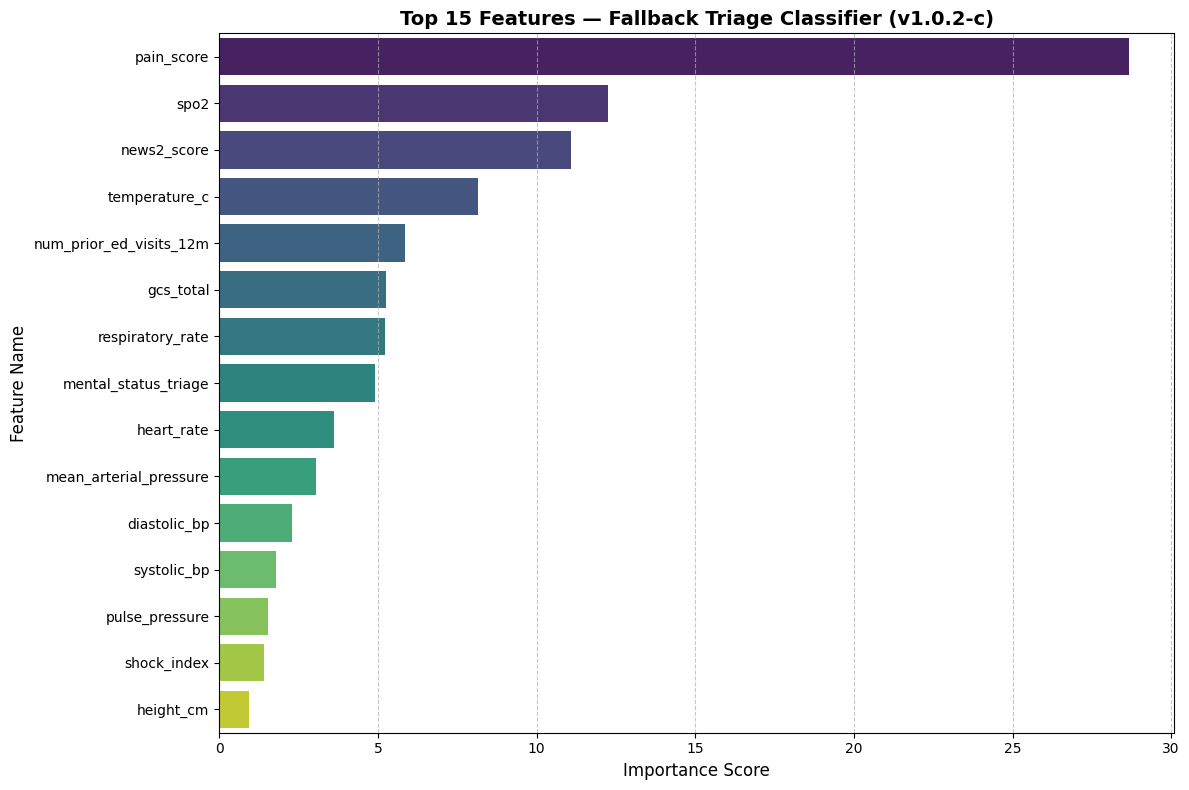

Metrics saved to ml/metrics/v1.0.2-c/


In [4]:
# Step 3 — Metrics & Visualization
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

metrics_dir = ML / "metrics/v1.0.2-c"

# --- Classification Report ---
report = classification_report(Y, oof_predictions)
print(report)

with open(metrics_dir / "classification_report.txt", "w") as f:
    f.write(f"V1.0.2-c FALLBACK TRIAGE CLASSIFIER (No Medical History)\n")
    f.write(f"OOF Accuracy: {accuracy_score(Y, oof_predictions) * 100:.2f}%\n\n")
    f.write(report)

# --- Feature Importance ---
fi = last_model.get_feature_importance(prettified=True)

plt.figure(figsize=(12, 8))
sns.barplot(x="Importances", y="Feature Id", hue="Feature Id", legend=False,
            data=fi.head(15), palette="viridis")
plt.title("Top 15 Features — Fallback Triage Classifier (v1.0.2-c)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(metrics_dir / "feature_importance.png", bbox_inches="tight", dpi=300)
plt.show()

print("Metrics saved to ml/metrics/v1.0.2-c/")


In [5]:
# Step 4 — Crown best fold + save training summary
import shutil
import json

src  = ML / f"models/v1.0.2-c/model_v1.0.2-c_fold_{best_fold}.cbm"
dest = ML / "models/v1.0.2-c/model_v1.0.2-c.cbm"
shutil.copy(str(src), str(dest))

fold_accuracies = {}
for fold, (train_idx, test_idx) in enumerate(
    StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=config["RANDOM_SEED"]).split(X, Y)
):
    fold_accuracies[f"fold_{fold+1}"] = round(
        accuracy_score(Y.iloc[test_idx], oof_predictions[test_idx]), 6
    )

summary = {
    "model_version": "v1.0.2-c",
    "best_fold": best_fold,
    "best_fold_accuracy": round(best_score, 6),
    "oof_pipeline_accuracy": round(accuracy_score(Y, oof_predictions), 6),
    "fold_accuracies": fold_accuracies
}

summary_path = ML / "metrics/v1.0.2-c/training_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print(f"Champion: Fold {best_fold}  —  {best_score * 100:.2f}%")
print(f"OOF Pipeline Accuracy: {accuracy_score(Y, oof_predictions) * 100:.2f}%")
print(f"\nArtifacts ready:")
print(f"  Model:   ml/models/v1.0.2-c/model_v1.0.2-c.cbm")
print(f"  Summary: ml/metrics/v1.0.2-c/training_summary.json")


Champion: Fold 4  —  86.16%
OOF Pipeline Accuracy: 85.89%

Artifacts ready:
  Model:   ml/models/v1.0.2-c/model_v1.0.2-c.cbm
  Summary: ml/metrics/v1.0.2-c/training_summary.json
